# Entrenamiento CNN con Tensores Multiespectrales (Maíz)

Entrena una CNN para clasificar tratamientos de maíz usando tensores multicanal `H x W x 10`.

## 0. Librerías

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    cohen_kappa_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

tf.keras.utils.set_random_seed(42)

## 1. Configuración

In [2]:
# Dataset multiespectral
base_dir      = "extracted_tensors_maiz_split"
manifest_path = "datasets/object_split_maiz_tensors.csv"

# Los tensores nativos son 240x240x10; se redimensionan a 128x128 en la pipeline
IMG_HEIGHT   = 128
IMG_WIDTH    = 128
NUM_CHANNELS = 10
BATCH_SIZE   = 16

# Entrenamiento
EPOCHS        = 100
LEARNING_RATE = 3e-4

# Normalización: zscore_masked
NORMALIZATION_MODE = "zscore_masked"

# Regularización
L2_LAMBDA      = 1e-4
DROPOUT_BLOCK1 = 0.20
DROPOUT_BLOCK2 = 0.30
DROPOUT_BLOCK3 = 0.35
DROPOUT_DENSE  = 0.40

print("Configuración:")
print(f"- EPOCHS={EPOCHS}, LR={LEARNING_RATE}, BATCH_SIZE={BATCH_SIZE}")
print(f"- NORMALIZATION_MODE={NORMALIZATION_MODE}")
print(f"- L2_LAMBDA={L2_LAMBDA}")
print(f"- DROPOUTS=({DROPOUT_BLOCK1}, {DROPOUT_BLOCK2}, {DROPOUT_BLOCK3}, {DROPOUT_DENSE})")

Configuración:
- EPOCHS=100, LR=0.0003, BATCH_SIZE=16
- NORMALIZATION_MODE=zscore_masked
- L2_LAMBDA=0.0001
- DROPOUTS=(0.2, 0.3, 0.35, 0.4)


## 2. Carga de manifest y validación inicial

In [3]:
if not os.path.isfile(manifest_path):
    raise FileNotFoundError(f"No existe manifest: {manifest_path}")

manifest_df = pd.read_csv(manifest_path)
required_cols = {"object_id", "split", "tensor_path", "tratamiento", "plant_id"}
missing_cols = required_cols - set(manifest_df.columns)
if missing_cols:
    raise ValueError(f"Faltan columnas en manifest: {sorted(missing_cols)}")

manifest_df = manifest_df.copy()
manifest_df["tensor_path"] = manifest_df["tensor_path"].astype(str)
manifest_df["object_id"]   = manifest_df["object_id"].astype(str)
manifest_df["plant_id"]    = manifest_df["plant_id"].astype(str)
manifest_df["tratamiento"] = manifest_df["tratamiento"].astype(int)
manifest_df["class_name"]  = manifest_df["tratamiento"].map(lambda t: f"T{t}")

# Verificar existencia de archivos de tensor
manifest_df["exists"] = manifest_df["tensor_path"].map(os.path.isfile)
n_missing = int((~manifest_df["exists"]).sum())
if n_missing > 0:
    display(manifest_df.loc[~manifest_df["exists"], ["object_id", "tensor_path"]].head(10))
    raise ValueError(f"Hay {n_missing} rutas de tensor no existentes.")

print("Registros en manifest:", len(manifest_df))
print("\nConteo por split:")
print(manifest_df["split"].value_counts().to_string())
print("\nClases detectadas:", sorted(manifest_df["class_name"].unique().tolist()))
manifest_df.head()

Registros en manifest: 576

Conteo por split:
split
train    401
test      91
val       84

Clases detectadas: ['T1', 'T2', 'T3', 'T4']


,cultivo,fecha,plant_id,tratamiento,object_id,split,tensor_path,preview_path,height,width,channels,dtype,nonzero_voxels,source_ref_file,source_class_file,num_genotipos,max_objects_rule,synthetic_splits,class_name,exists
0,maiz,Jun_23_2022,REF__0002_T1R1G10G4,1,REF__0002_T1R1G10G4__obj_001,train,extracted_tensors_maiz_split\train\T1\REF__000...,extracted_tensors_maiz_split\train\T1\REF__000...,240,240,10,float32,33070,REF__0002_T1R1G10G4.mat,CLASS__0002_T1R1G10G4.mat,2,8,0,T1,True
1,maiz,Jun_23_2022,REF__0002_T1R1G10G4,1,REF__0002_T1R1G10G4__obj_002,train,extracted_tensors_maiz_split\train\T1\REF__000...,extracted_tensors_maiz_split\train\T1\REF__000...,240,240,10,float32,29370,REF__0002_T1R1G10G4.mat,CLASS__0002_T1R1G10G4.mat,2,8,0,T1,True
2,maiz,Jun_23_2022,REF__0002_T1R1G10G4,1,REF__0002_T1R1G10G4__obj_003,test,extracted_tensors_maiz_split\test\T1\REF__0002...,extracted_tensors_maiz_split\test\T1\REF__0002...,240,240,10,float32,18240,REF__0002_T1R1G10G4.mat,CLASS__0002_T1R1G10G4.mat,2,8,0,T1,True
3,maiz,Jun_23_2022,REF__0002_T1R1G10G4,1,REF__0002_T1R1G10G4__obj_004,val,extracted_tensors_maiz_split\val\T1\REF__0002_...,extracted_tensors_maiz_split\val\T1\REF__0002_...,240,240,10,float32,29900,REF__0002_T1R1G10G4.mat,CLASS__0002_T1R1G10G4.mat,2,8,0,T1,True
4,maiz,Jun_23_2022,REF__0002_T1R1G10G4,1,REF__0002_T1R1G10G4__obj_005,test,extracted_tensors_maiz_split\test\T1\REF__0002...,extracted_tensors_maiz_split\test\T1\REF__0002...,240,240,10,float32,28100,REF__0002_T1R1G10G4.mat,CLASS__0002_T1R1G10G4.mat,2,8,0,T1,True


## 3. Construcción de splits

In [4]:
# Usar los splits definidos en el manifest
train_df = manifest_df[manifest_df["split"] == "train"].copy()
val_df   = manifest_df[manifest_df["split"] == "val"].copy()
test_df  = manifest_df[manifest_df["split"] == "test"].copy()

for df in [train_df, val_df, test_df]:
    if df.empty:
        raise ValueError(f"Split vacio en manifest.")

class_names  = sorted(train_df["class_name"].unique().tolist())
class_to_idx = {c: i for i, c in enumerate(class_names)}

for df in [train_df, val_df, test_df]:
    df["label"] = df["class_name"].map(class_to_idx).astype(int)

train_paths  = train_df["tensor_path"].values
train_labels = train_df["label"].values
val_paths    = val_df["tensor_path"].values
val_labels   = val_df["label"].values
test_paths   = test_df["tensor_path"].values
test_labels  = test_df["label"].values

print(f"Train: {len(train_paths):,} | Val: {len(val_paths):,} | Test: {len(test_paths):,}")
print("Clases:", class_names)
print("\nDistribución por clase:")
for split_name, labels in [("train", train_labels), ("val", val_labels), ("test", test_labels)]:
    counts = {class_names[i]: int((labels == i).sum()) for i in range(len(class_names))}
    print(f"  {split_name}: {counts}")

Train: 401 | Val: 84 | Test: 91
Clases: ['T1', 'T2', 'T3', 'T4']

Distribución por clase:
  train: {'T1': 128, 'T2': 117, 'T3': 78, 'T4': 78}
  val: {'T1': 27, 'T2': 25, 'T3': 16, 'T4': 16}
  test: {'T1': 29, 'T2': 26, 'T3': 18, 'T4': 18}


## 4. Validación del dataset

In [5]:
train_objects = set(train_df["object_id"].unique())
val_objects   = set(val_df["object_id"].unique())
test_objects  = set(test_df["object_id"].unique())

overlap_train_test = train_objects & test_objects
overlap_val_test   = val_objects   & test_objects
overlap_train_val  = train_objects & val_objects

if overlap_train_test:
    raise ValueError(f"CRUCE train-test: {len(overlap_train_test)} objetos.")
if overlap_val_test:
    raise ValueError(f"CRUCE val-test: {len(overlap_val_test)} objetos.")

print(f"Cruce train-test: {len(overlap_train_test)} (esperado: 0)")
print(f"Cruce val-test:   {len(overlap_val_test)} (esperado: 0)")
print(f"Cruce train-val:  {len(overlap_train_val)} (informativo)")

# Conteo de objetos (hojas) por imagen/plant_id y split
Leave_per_image_split = (
    manifest_df.groupby(["plant_id", "split"])
    .size()
    .unstack(fill_value=0)
)

expected_splits = ["train", "val", "test"]
Leave_per_image_split = Leave_per_image_split.reindex(columns=expected_splits, fill_value=0)

print(f"   Imágenes totales: {manifest_df['plant_id'].nunique()}")

only_train = (Leave_per_image_split[["val", "test"]].sum(axis=1) == 0) & (Leave_per_image_split["train"] > 0)
print(f"   Imágenes con hojas SOLO en train: {int(only_train.sum())}")

multi_split = (Leave_per_image_split.gt(0).sum(axis=1) > 1).sum()
print(f"   Imágenes con hojas en VARIOS splits (esperado): {int(multi_split)}")

Cruce train-test: 0 (esperado: 0)
Cruce val-test:   0 (esperado: 0)
Cruce train-val:  0 (informativo)
   Imágenes totales: 66
   Imágenes con hojas SOLO en train: 4
   Imágenes con hojas en VARIOS splits (esperado): 62


## 5. Pipeline para tensores multicanal

In [6]:
def _read_npy_tensor(path_bytes):
    path = path_bytes.decode("utf-8")
    arr = np.load(path).astype(np.float32)
    if arr.ndim != 3:
        raise ValueError(f"Tensor inválido en {path}. shape={arr.shape}")
    return arr


def load_and_preprocess_tensor(path, label):
    tensor = tf.numpy_function(_read_npy_tensor, [path], tf.float32)
    tensor.set_shape([None, None, NUM_CHANNELS])

    # Redimensionar de 240x240 nativo a 128x128 para reducir carga computacional
    tensor = tf.image.resize(tensor, [IMG_HEIGHT, IMG_WIDTH], method="bilinear")
    tensor.set_shape([IMG_HEIGHT, IMG_WIDTH, NUM_CHANNELS])

    # Sanitización: NaN/Inf -> 0
    tensor = tf.where(tf.math.is_finite(tensor), tensor, tf.zeros_like(tensor))

    # zscore_masked: z-score solo sobre píxeles de hoja (no-zero)
    mask   = tf.cast(tf.reduce_any(tensor != 0, axis=-1, keepdims=True), tf.float32)
    n_leaf = tf.maximum(tf.reduce_sum(mask), 1.0)
    mean   = tf.reduce_sum(tensor * mask, axis=[0, 1], keepdims=True) / n_leaf
    diff   = (tensor - mean) * mask
    var    = tf.reduce_sum(tf.square(diff), axis=[0, 1], keepdims=True) / n_leaf
    std    = tf.sqrt(var + 1e-6)
    tensor = diff / std

    return tensor, tf.cast(label, tf.int32)


def make_dataset(paths, labels, batch_size=BATCH_SIZE, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=123, reshuffle_each_iteration=True)
    ds = ds.map(load_and_preprocess_tensor, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds   = make_dataset(val_paths,   val_labels,   training=False)
test_ds  = make_dataset(test_paths,  test_labels,  training=False)

# Verificación rápida de dimensiones
for x_batch, y_batch in train_ds.take(1):
    print("Batch X shape:", x_batch.shape)
    print("Batch y shape:", y_batch.shape)
    print("Rango X: min=", float(tf.reduce_min(x_batch)), " max=", float(tf.reduce_max(x_batch)))

Batch X shape: (16, 128, 128, 10)
Batch y shape: (16,)
Rango X: min= -4.447686672210693  max= 6.863804817199707


In [7]:
def contar_por_clase(labels_array, class_names):
    counts = pd.Series(labels_array).value_counts().sort_index()
    out = []
    for idx, cname in enumerate(class_names):
        out.append(int(counts.get(idx, 0)))
    return pd.Series(out, index=class_names)

print("distribuciones train interno: ")
print(contar_por_clase(train_labels, class_names).to_string())
print("Distribución val interna: ")
print(contar_por_clase(val_labels, class_names).to_string())
print("Distribución test final: ")
print(contar_por_clase(test_labels, class_names).to_string())

distribuciones train interno: 
T1    128
T2    117
T3     78
T4     78
Distribución val interna: 
T1    27
T2    25
T3    16
T4    16
Distribución test final: 
T1    29
T2    26
T3    18
T4    18


## 6. Visualización exploratoria

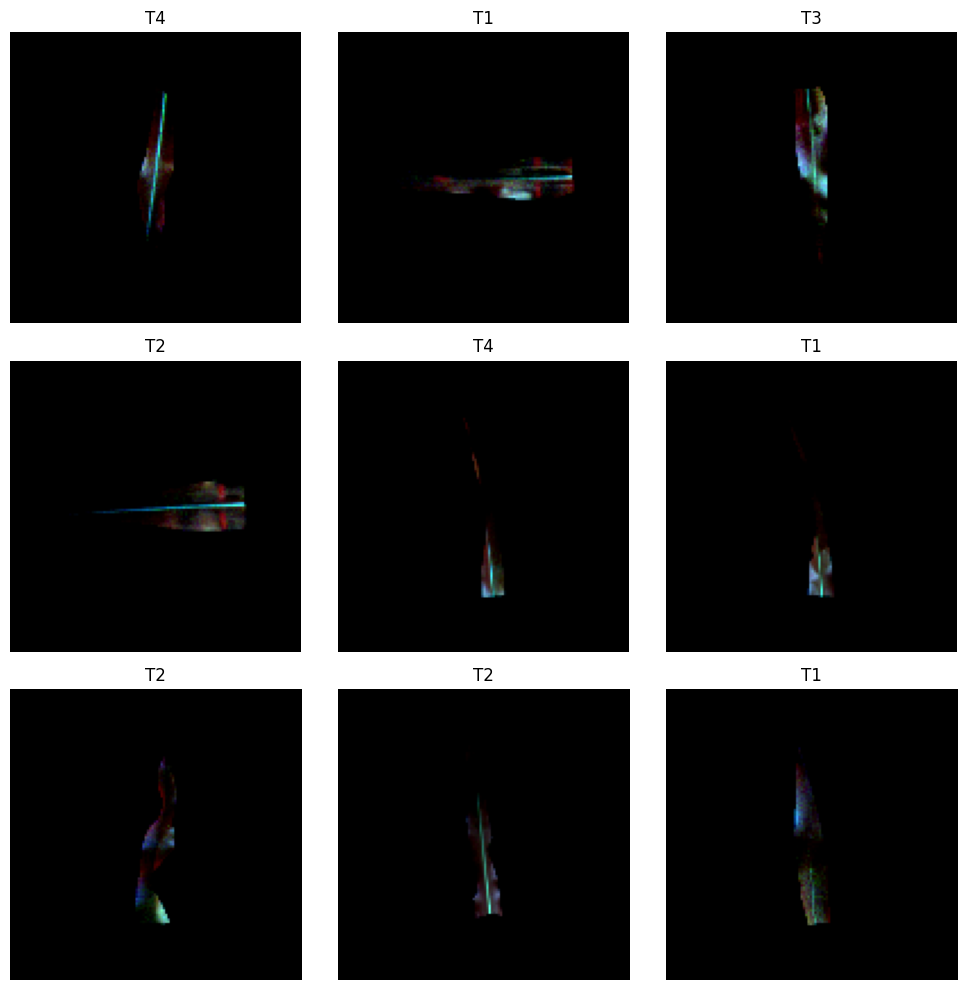

In [8]:
def tensor_to_rgb_preview(tensor, bands=(8, 4, 1)):
    b0, b1, b2 = bands
    rgb = np.stack([tensor[:, :, b0], tensor[:, :, b1], tensor[:, :, b2]], axis=-1)
    maxv = float(np.max(rgb))
    if maxv > 0:
        rgb = rgb / maxv
    return np.clip(rgb, 0.0, 1.0)


plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    images_np = images.numpy()
    labels_np = labels.numpy()
    n_show = min(9, images_np.shape[0])
    for i in range(n_show):
        ax = plt.subplot(3, 3, i + 1)
        rgb = tensor_to_rgb_preview(images_np[i], bands=(8, 4, 1))
        plt.imshow(rgb)
        plt.title(class_names[int(labels_np[i])])
        plt.axis("off")
plt.tight_layout()
plt.show()

## 7. Modelo CNN multicanal

In [9]:
num_classes = len(class_names)
reg = tf.keras.regularizers.l2(L2_LAMBDA)

# Aumentación geométrica
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.12),
    layers.RandomZoom(0.12),
    layers.GaussianNoise(0.02),
], name="data_augmentation")

inputs = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, NUM_CHANNELS))

x = data_augmentation(inputs)

# Mezcla espectral
x = layers.Conv2D(NUM_CHANNELS * 2, 1, padding="same", activation="relu",
                  kernel_regularizer=reg, name="spectral_mixing")(x)
x = layers.BatchNormalization()(x)

# Bloque 1: 128×128 -> 64×64
x = layers.SeparableConv2D(32, 3, padding="same", activation="relu",
                            depthwise_regularizer=reg, pointwise_regularizer=reg)(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)
x = layers.Dropout(DROPOUT_BLOCK1)(x)

# Bloque 2: 64×64 -> 32×32
x = layers.SeparableConv2D(64, 3, padding="same", activation="relu",
                            depthwise_regularizer=reg, pointwise_regularizer=reg)(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)
x = layers.Dropout(DROPOUT_BLOCK2)(x)

# Bloque 3: 32×32 -> 16×16
x = layers.SeparableConv2D(128, 3, padding="same", activation="relu",
                            depthwise_regularizer=reg, pointwise_regularizer=reg)(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)
x = layers.Dropout(DROPOUT_BLOCK3)(x)

# Agregación global
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation="relu", kernel_regularizer=reg)(x)
x = layers.Dropout(DROPOUT_DENSE)(x)
outputs = layers.Dense(num_classes)(x)

model = tf.keras.Model(inputs, outputs, name="maiz_spectral_cnn")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

model.summary()

Model: "maiz_spectral_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spectral_mixing (Conv2D)        │ (None, 128, 128, 20)   │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 20)   │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 128, 128, 32)   │           852 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 64, 64, 64)     │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 32, 32, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,860 (85.39 KB)

 Trainable params: 21,372 (83.48 KB)

 Non-trainable params: 488 (1.91 KB)

## 8. Entrenamiento

In [10]:
# Class weights: compensar el desbalance T1/T2 (~130) vs T3/T4 (~77)
classes = np.unique(train_labels)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_labels)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
print("Class weights:", {class_names[k]: round(v, 3) for k, v in class_weight.items()})

suffix          = f"spectral_cnn_{NORMALIZATION_MODE}"
best_model_path = f"models/maiz/maiz_model_cnn_multispectral_tensor_{suffix}.keras"
history_csv     = f"results/training_history_maiz_cnn_multispectral_tensor_{suffix}.csv"
os.makedirs(os.path.dirname(best_model_path), exist_ok=True)
os.makedirs(os.path.dirname(history_csv), exist_ok=True)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=7,
        min_lr=1e-6,
        verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.CSVLogger(history_csv, append=False),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks,
)

print(f"\nCheckpoint guardado en: {best_model_path}")
print(f"Historial en: {history_csv}")

Class weights: {'T1': 0.783, 'T2': 0.857, 'T3': 1.285, 'T4': 1.285}
Epoch 1/100


25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.2762 - loss: 1.4857
Epoch 1: val_accuracy improved from None to 0.19048, saving model to models/maiz/maiz_model_cnn_multispectral_tensor_spectral_cnn_zscore_masked.keras

Epoch 1: finished saving model to models/maiz/maiz_model_cnn_multispectral_tensor_spectral_cnn_zscore_masked.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 505ms/step - accuracy: 0.2793 - loss: 1.4673 - val_accuracy: 0.1905 - val_loss: 1.4135 - learning_rate: 3.0000e-04
Epoch 2/100
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.2848 - loss: 1.3999
Epoch 2: val_accuracy did not improve from 0.19048
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 491ms/step - accuracy: 0.2594 - loss: 1.4404 - val_accuracy: 0.1905 - val_loss: 1.4157 - learning_rate: 3.0000e-04
Epoch 3/100
25/26 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - accuracy: 0.2684 - loss: 1.4372
Epoch 3: val_accuracy did not improve from 0.19048
26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 534ms/step - accuracy: 0.2569 - loss: 1.4234 - val_accuracy:

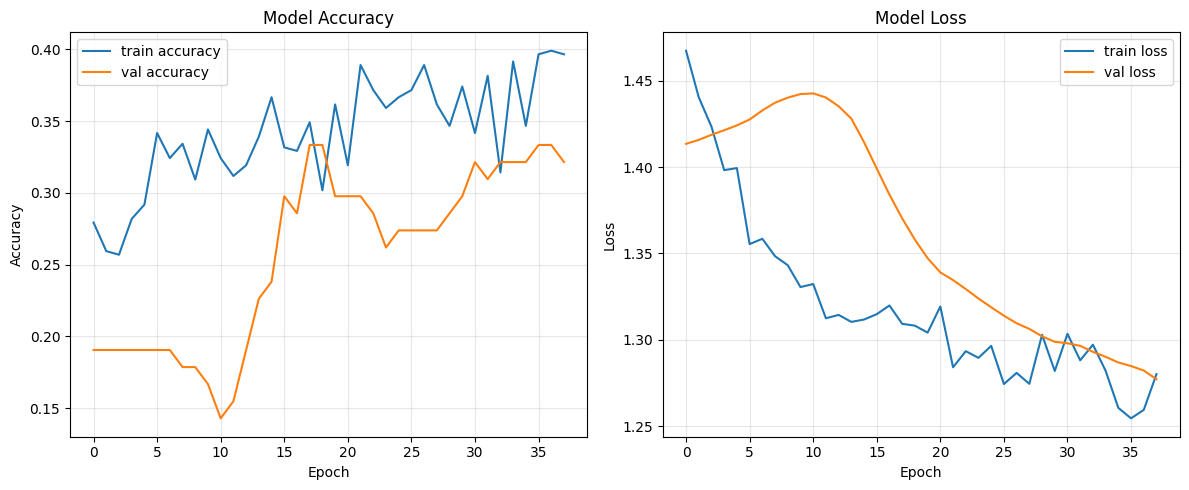

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="val accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Evaluación

In [12]:
trained_model = model

print("Modelo listo para evaluación (best val_accuracy restaurado por EarlyStopping).")
print(f"Checkpoint disponible en: {best_model_path}")

Modelo listo para evaluación (best val_accuracy restaurado por EarlyStopping).
Checkpoint disponible en: models/maiz/maiz_model_cnn_multispectral_tensor_spectral_cnn_zscore_masked.keras


In [13]:
def collect_predictions(ds, model):
    y_true, y_pred = [], []
    for x_batch, y_batch in ds:
        logits = model.predict(x_batch, verbose=0)
        preds  = np.argmax(logits, axis=1)
        y_true.extend(y_batch.numpy())
        y_pred.extend(preds)
    return np.array(y_true), np.array(y_pred)


print("Prediciendo train...")
y_train_true, y_train_pred = collect_predictions(train_ds, trained_model)
print("Prediciendo val...")
y_val_true, y_val_pred     = collect_predictions(val_ds,   trained_model)
print("Prediciendo test...")
y_test_true, y_test_pred   = collect_predictions(test_ds,  trained_model)

Prediciendo train...
Prediciendo val...
Prediciendo test...


In [14]:
def resumen_predicciones(y_true, y_pred, class_names, titulo):
    print(f"\n=== {titulo} ===")
    true_counts = np.bincount(y_true, minlength=len(class_names))
    pred_counts = np.bincount(y_pred, minlength=len(class_names))
    df = pd.DataFrame({"clase": class_names, "true": true_counts, "pred": pred_counts})
    df["pred_pct"] = (df["pred"] / max(1, df["pred"].sum()) * 100).round(2)
    print(df.to_string(index=False))


resumen_predicciones(y_train_true, y_train_pred, class_names, "Train")
resumen_predicciones(y_val_true,   y_val_pred,   class_names, "Val")
resumen_predicciones(y_test_true,  y_test_pred,  class_names, "Test")


=== Train ===
clase  true  pred  pred_pct
   T1   128    73     18.20
   T2   117    30      7.48
   T3    78   287     71.57
   T4    78    11      2.74

=== Val ===
clase  true  pred  pred_pct
   T1    27    11     13.10
   T2    25    10     11.90
   T3    16    62     73.81
   T4    16     1      1.19

=== Test ===
clase  true  pred  pred_pct
   T1    29    15     16.48
   T2    26    10     10.99
   T3    18    65     71.43
   T4    18     1      1.10


In [15]:
# Métricas resumidas
train_accuracy  = accuracy_score(y_train_true, y_train_pred)
train_precision = precision_score(y_train_true, y_train_pred, average="macro", zero_division=0)
train_f1        = f1_score(y_train_true, y_train_pred, average="macro", zero_division=0)
train_kappa     = cohen_kappa_score(y_train_true, y_train_pred)

test_accuracy   = accuracy_score(y_test_true, y_test_pred)
test_precision  = precision_score(y_test_true, y_test_pred, average="macro", zero_division=0)
test_f1         = f1_score(y_test_true, y_test_pred, average="macro", zero_division=0)
test_kappa      = cohen_kappa_score(y_test_true, y_test_pred)

print("-" * 70)
print(f"{'Métrica':<22} | {'Train':<20} | {'Test':<20}")
print("-" * 70)
print(f"{'Accuracy':<22} | {train_accuracy:<20.4f} | {test_accuracy:<20.4f}")
print(f"{'Precision (macro)':<22} | {train_precision:<20.4f} | {test_precision:<20.4f}")
print(f"{'F1-Score (macro)':<22} | {train_f1:<20.4f} | {test_f1:<20.4f}")
print(f"{'Kappa Score':<22} | {train_kappa:<20.4f} | {test_kappa:<20.4f}")
print("-" * 70)

----------------------------------------------------------------------
Métrica                | Train                | Test                
----------------------------------------------------------------------
Accuracy               | 0.3017               | 0.3187              
Precision (macro)      | 0.3715               | 0.3071              
F1-Score (macro)       | 0.2449               | 0.2514              
Kappa Score            | 0.0996               | 0.1182              
----------------------------------------------------------------------


In [16]:
print("Reporte de clasificación (Test):")
print(classification_report(y_test_true, y_test_pred, target_names=class_names, zero_division=0))

print("\nReporte de clasificación (Train):")
print(classification_report(y_train_true, y_train_pred, target_names=class_names, zero_division=0))

print("\nReporte de clasificación (Val):")
print(classification_report(y_val_true, y_val_pred, target_names=class_names, zero_division=0))

Reporte de clasificación (Test):
              precision    recall  f1-score   support

          T1       0.47      0.24      0.32        29
          T2       0.50      0.19      0.28        26
          T3       0.26      0.94      0.41        18
          T4       0.00      0.00      0.00        18

    accuracy                           0.32        91
   macro avg       0.31      0.34      0.25        91
weighted avg       0.34      0.32      0.26        91


Reporte de clasificación (Train):
              precision    recall  f1-score   support

          T1       0.44      0.25      0.32       128
          T2       0.43      0.11      0.18       117
          T3       0.25      0.92      0.39        78
          T4       0.36      0.05      0.09        78

    accuracy                           0.30       401
   macro avg       0.37      0.33      0.24       401
weighted avg       0.39      0.30      0.25       401


Reporte de clasificación (Val):
              precision    re

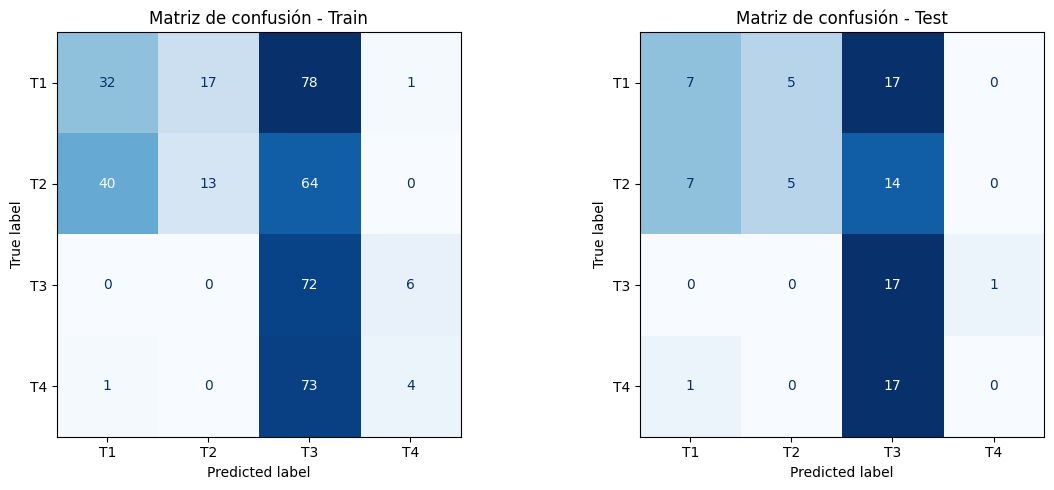

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_train = confusion_matrix(y_train_true, y_train_pred)
ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=class_names).plot(
    ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Matriz de confusión - Train")
axes[0].grid(False)

cm_test = confusion_matrix(y_test_true, y_test_pred)
ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names).plot(
    ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Matriz de confusión - Test")
axes[1].grid(False)

plt.tight_layout()
plt.show()

## 10. Grad-CAM: visualización de zonas de activación

Grad-CAM calcula los gradientes de la clase predicha respecto a los mapas de activación de la última capa convolucional (`SeparableConv2D`). Zonas con gradientes altos → el modelo considera esa región espacial determinante para la clasificación.

In [18]:
def _get_last_conv_layer_name(model):
    """Retorna el nombre de la última SeparableConv2D o Conv2D del modelo."""
    for layer in reversed(model.layers):
        if isinstance(layer, (tf.keras.layers.SeparableConv2D, tf.keras.layers.Conv2D)):
            return layer.name
    raise ValueError("No se encontró capa convolucional en el modelo.")


def gradcam_heatmap(img_array, model, conv_layer_name, class_index=None):
    """
    Calcula el mapa de calor Grad-CAM para una muestra.

    img_array   : np.ndarray de shape (1, H, W, C), ya normalizado.
    class_index : índice de clase objetivo; si None, usa la predicción del modelo.
    Retorna     : (heatmap np.ndarray shape (h_conv, w_conv) en [0,1], class_index usado)
    """
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(conv_layer_name).output, model.output],
    )
    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_tensor, training=False)
        if class_index is None:
            class_index = int(tf.argmax(preds[0]))
        score = preds[:, class_index]

    grads  = tape.gradient(score, conv_out)                      # (1, h, w, filters)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))               # (filters,)
    cam    = tf.squeeze(conv_out[0] @ pooled[..., tf.newaxis])   # (h, w)
    cam    = tf.nn.relu(cam).numpy()
    if cam.max() > 0:
        cam = cam / cam.max()
    return cam, class_index


def overlay_heatmap(img_rgb, heatmap, alpha=0.50):
    """Superpone heatmap sobre img_rgb usando resize bilineal de TensorFlow."""
    H, W = img_rgb.shape[:2]
    cam_resized = tf.image.resize(
        heatmap[..., np.newaxis], [H, W], method="bilinear"
    ).numpy().squeeze()
    colored = plt.cm.jet(cam_resized)[:, :, :3]
    return np.clip((1 - alpha) * img_rgb + alpha * colored, 0, 1), cam_resized


last_conv_layer = _get_last_conv_layer_name(trained_model)
print(f"Capa objetivo Grad-CAM: '{last_conv_layer}'")

# En Keras 3 algunos layers ya no exponen .output_shape; usar layer.output.shape es más robusto
target_layer = trained_model.get_layer(last_conv_layer)
activation_shape = getattr(target_layer, "output_shape", None)
if activation_shape is None:
    activation_shape = tuple(target_layer.output.shape)
print(f"Shape de activaciones: {activation_shape}")

Capa objetivo Grad-CAM: 'separable_conv2d_2'
Shape de activaciones: (None, 32, 32, 128)


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_16168\2971601905.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 1])


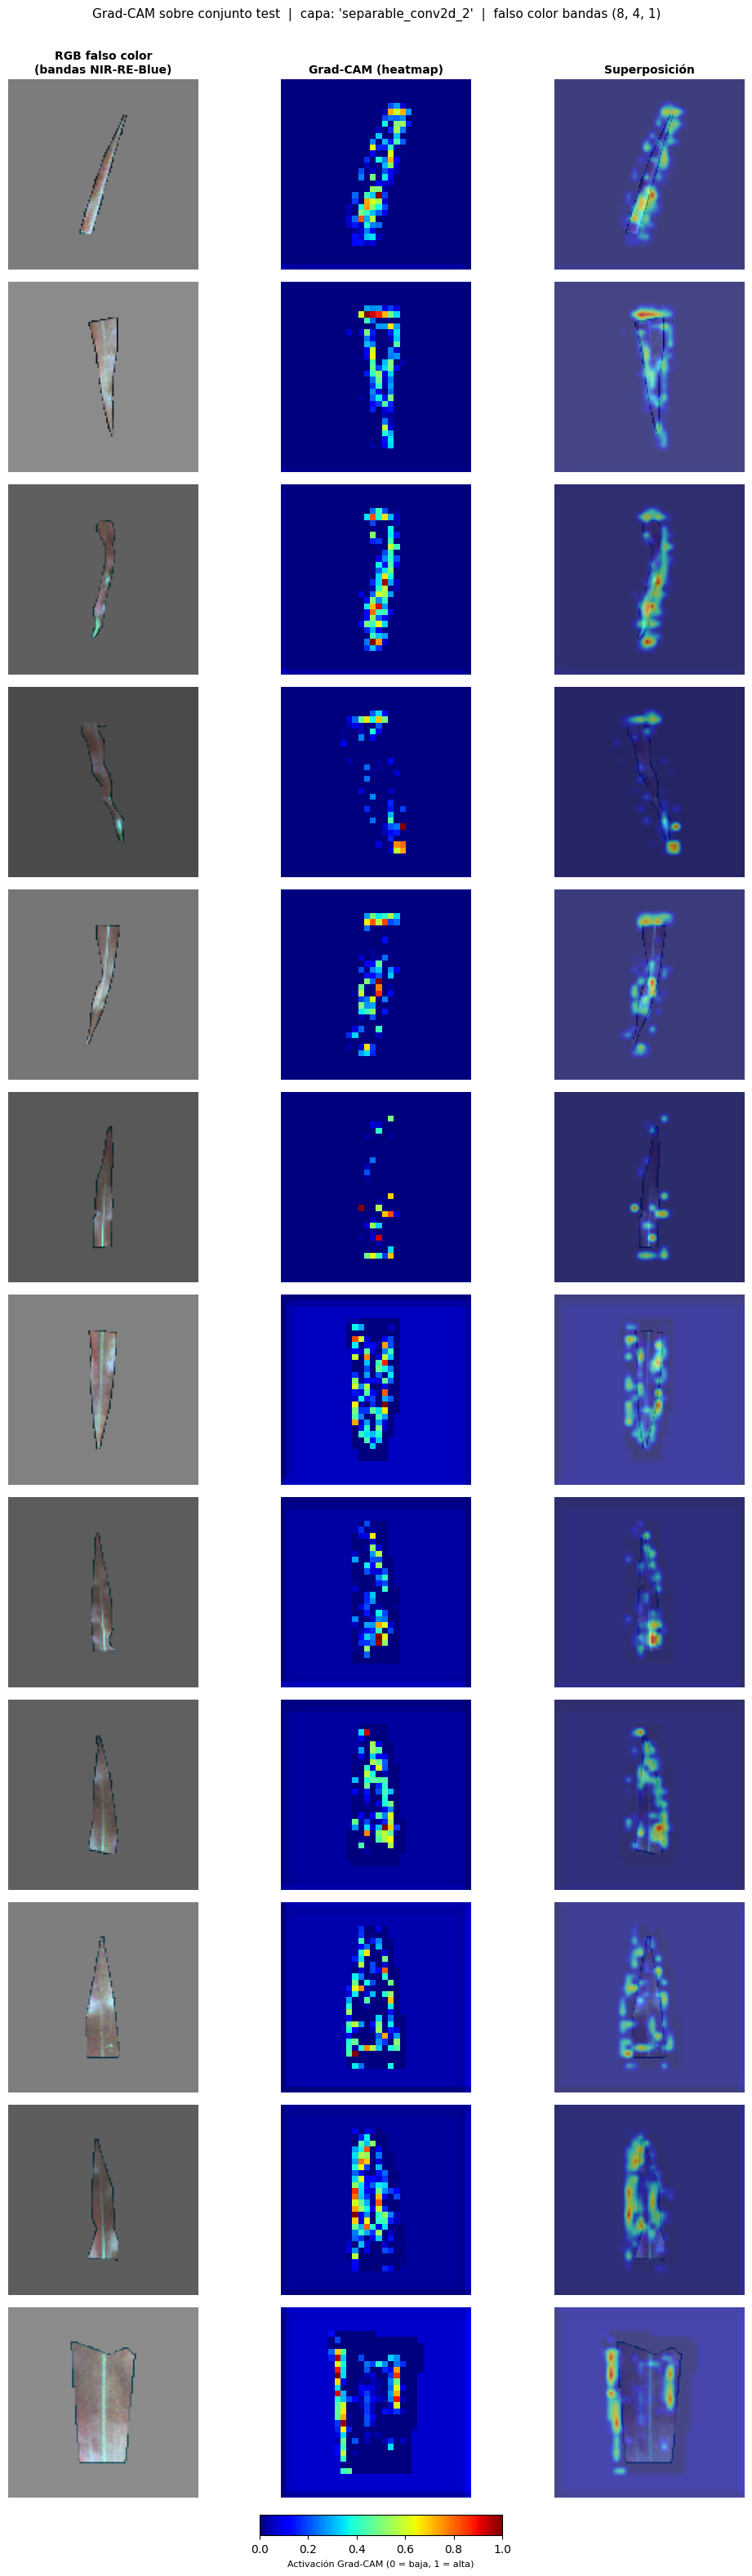

In [19]:
# Parámetros de visualización
N_PER_CLASS   = 3      # muestras de test por clase
ALPHA_OVERLAY = 0.50   # peso del heatmap en la superposición
BANDS_RGB     = (8, 4, 1)  # bandas para falso color (NIR, Red-Edge, Blue)

# ── Recolectar hasta N_PER_CLASS tensores de test por clase ───────────────
samples_by_class = {i: [] for i in range(len(class_names))}
for xb, yb in test_ds:
    for xi, yi in zip(xb.numpy(), yb.numpy()):
        lbl = int(yi)
        if len(samples_by_class[lbl]) < N_PER_CLASS:
            samples_by_class[lbl].append(xi)
    if all(len(v) >= N_PER_CLASS for v in samples_by_class.values()):
        break

# ── Grid: [clase × muestra] filas, 3 columnas ────────────────────────────
total_rows = len(class_names) * N_PER_CLASS
fig, axes = plt.subplots(total_rows, 3, figsize=(11, 2.6 * total_rows))

col_titles = ["RGB falso color\n(bandas NIR-RE-Blue)", "Grad-CAM (heatmap)", "Superposición"]
for col, ct in enumerate(col_titles):
    axes[0, col].set_title(ct, fontsize=10, fontweight="bold")

row = 0
for cls_idx, cls_name in enumerate(class_names):
    for sample_i, tensor in enumerate(samples_by_class[cls_idx][:N_PER_CLASS]):
        img_input = tensor[np.newaxis]  # (1, H, W, C)

        # Grad-CAM usando la clase verdadera
        cam, _ = gradcam_heatmap(img_input, trained_model, last_conv_layer,
                                  class_index=cls_idx)

        # Predicción real para indicar si es correcta
        _, pred_auto = gradcam_heatmap(img_input, trained_model, last_conv_layer)
        is_correct  = pred_auto == cls_idx
        result_str  = "✓" if is_correct else f"✗ → {class_names[pred_auto]}"

        # Falso color
        b0, b1, b2 = BANDS_RGB
        rgb = np.stack([tensor[:, :, b0], tensor[:, :, b1], tensor[:, :, b2]], axis=-1)
        rmin, rmax = rgb.min(), rgb.max()
        rgb_norm = np.clip((rgb - rmin) / (rmax - rmin + 1e-6), 0, 1)

        overlay, _ = overlay_heatmap(rgb_norm, cam, alpha=ALPHA_OVERLAY)

        axes[row, 0].imshow(rgb_norm)
        axes[row, 0].set_ylabel(f"{cls_name}  #{sample_i + 1}\n({result_str})",
                                fontsize=8, labelpad=4)
        axes[row, 0].axis("off")

        im = axes[row, 1].imshow(cam, cmap="jet", vmin=0, vmax=1)
        axes[row, 1].axis("off")

        axes[row, 2].imshow(overlay)
        axes[row, 2].axis("off")

        row += 1

# Barra de color global
cbar_ax = fig.add_axes([0.37, 0.01, 0.27, 0.008])
plt.colorbar(im, cax=cbar_ax, orientation="horizontal").set_label(
    "Activación Grad-CAM (0 = baja, 1 = alta)", fontsize=8
)

plt.suptitle(
    f"Grad-CAM sobre conjunto test  |  capa: '{last_conv_layer}'  |  "
    f"falso color bandas {BANDS_RGB}",
    fontsize=11, y=1.002,
)
plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()

## 11. Guardado de artefactos

In [20]:
final_model_path = "models/maiz/maiz_model_cnn_multispectral_tensor_final.keras"
trained_model.save(final_model_path)
print(f"Modelo final guardado en: {final_model_path}")
print(f"Mejor checkpoint: {best_model_path}")
print(f"Historial: {history_csv}")

Modelo final guardado en: models/maiz/maiz_model_cnn_multispectral_tensor_final.keras
Mejor checkpoint: models/maiz/maiz_model_cnn_multispectral_tensor_spectral_cnn_zscore_masked.keras
Historial: results/training_history_maiz_cnn_multispectral_tensor_spectral_cnn_zscore_masked.csv
